### Early In-Hospital Mortality Prediction Using First 24-Hour Clinical Data

**Project**: Can clinical information available during the **first 24 hours** of **hospitalization** predict **in-hospital mortality** among **adult** patients? (Multivariate Predictive Analysis)

Clinical motivation:
Early identification of patients at high risk of death could help clinicians
1. recognize high-risk patients sooner,
2. increase monitoring and reassessment, and
3. consider appropriate escalation of care.


* The unit of analysis is hadm_id, i.e. hospitalization, with 275 admissions from 100 patients.

* The target is:
hospital_expire_flag
with:
260 survivors
15 deaths
mortality prevalence ≈ 5.45%


Because this project uses a small demonstration dataset with relatively few mortality events, the results should be considered **exploratory and educational rather than clinically deployable**.

**Note**: This project uses the MIMIC-IV Clinical Database Demo (v2.2), a publicly available, de-identified subset of MIMIC-IV, hosted on PhysioNet.

**Citation**:

APA	Pollard, T., Moody, B. E., Lehman, L., Gow, B., Fernandes, C., Xie, C., Johnson, A., Mark, R. G., & Heldt, T. (2026). PhysioNet as a global platform for biomedical research. Nature Health. https://doi.org/10.1038/s44360-026-00096-z. Available from: https://rdcu.be/faatM

MLA	Pollard, Tom, et al. “PhysioNet as a Global Platform for Biomedical Research.” Nature Health, 2026, https://doi.org/10.1038/s44360-026-00096-z. Available from: https://rdcu.be/faatM

CHICAGO	Pollard, Tom, Benjamin E. Moody, Li-wei Lehman, Brian Gow, Chrystinne Fernandes, Chen Xie, Alistair Johnson, Roger G. Mark, and Thomas Heldt. “PhysioNet as a Global Platform for Biomedical Research.” Nature Health (2026). https://doi.org/10.1038/s44360-026-00096-z.i Available from: https://rdcu.be/faatM

HARVARD	Pollard, T., Moody, B.E., Lehman, L., Gow, B., Fernandes, C., Xie, C., Johnson, A., Mark, R.G. and Heldt, T., 2026. PhysioNet as a global platform for biomedical research. Nature Health. Available at: https://doi.org/10.1038/s44360-026-00096-z. Available from: https://rdcu.be/faatM

VANCOUVER	Pollard T, Moody BE, Lehman L, Gow B, Fernandes C, Xie C, et al. PhysioNet as a global platform for biomedical research. Nature Health. 2026. doi:10.1038/s44360-026-00096-z. Available from: https://rdcu.be/faatM

The dataset is not included in this repository. Please download it directly from PhysioNet before running the notebook.
* Access page:
https://physionet.org/content/mimic-iv-demo/2.2/

* Setup:
1. Download the MIMIC-IV Clinical Database Demo (v2.2) from PhysioNet.
2. Extract the downloaded archive.
3. Place the hosp and icu folders inside a directory named mimic_data.
4. Run the notebook from the beginning.






# Understanding Dataset for Feature Extraction

In [1]:
import pandas as pd
import numpy as np

In [3]:
import os

all_items = os.listdir('mimic_data')
csv_files = [f for f in all_items if f.endswith('.csv') or f.endswith('.csv.gz')]
non_csv_items = [f for f in all_items if f not in csv_files]

print("Total items in mimic_data:", len(all_items))
print(all_items)


Total items in mimic_data: 32
['services.csv.gz', 'provider.csv.gz', 'ingredientevents.csv.gz', 'pharmacy.csv.gz', 'emar_detail.csv.gz', 'admissions.csv.gz', 'd_labitems.csv.gz', 'patients.csv.gz', 'inputevents.csv.gz', 'microbiologyevents.csv.gz', 'emar.csv.gz', 'procedureevents.csv.gz', 'outputevents.csv.gz', 'd_hcpcs.csv.gz', 'labevents.csv.gz', 'diagnoses_icd.csv.gz', 'procedures_icd.csv.gz', 'poe.csv.gz', 'hcpcsevents.csv.gz', 'prescriptions.csv.gz', 'omr.csv.gz', 'chartevents.csv.gz', 'index.html', 'd_icd_procedures.csv.gz', 'd_icd_diagnoses.csv.gz', 'd_items.csv.gz', 'transfers.csv.gz', 'icustays.csv.gz', 'datetimeevents.csv.gz', 'poe_detail.csv.gz', 'caregiver.csv.gz', 'drgcodes.csv.gz']


In [4]:
import os

files = os.listdir('mimic_data')
csv_files = [f for f in files if f.endswith('.csv') or f.endswith('.csv.gz')]
print(csv_files)
print("Number of files:", len(csv_files))

['services.csv.gz', 'provider.csv.gz', 'ingredientevents.csv.gz', 'pharmacy.csv.gz', 'emar_detail.csv.gz', 'admissions.csv.gz', 'd_labitems.csv.gz', 'patients.csv.gz', 'inputevents.csv.gz', 'microbiologyevents.csv.gz', 'emar.csv.gz', 'procedureevents.csv.gz', 'outputevents.csv.gz', 'd_hcpcs.csv.gz', 'labevents.csv.gz', 'diagnoses_icd.csv.gz', 'procedures_icd.csv.gz', 'poe.csv.gz', 'hcpcsevents.csv.gz', 'prescriptions.csv.gz', 'omr.csv.gz', 'chartevents.csv.gz', 'd_icd_procedures.csv.gz', 'd_icd_diagnoses.csv.gz', 'd_items.csv.gz', 'transfers.csv.gz', 'icustays.csv.gz', 'datetimeevents.csv.gz', 'poe_detail.csv.gz', 'caregiver.csv.gz', 'drgcodes.csv.gz']
Number of files: 31


In [5]:
for file in csv_files:
    sample = pd.read_csv(f'mimic_data/{file}', nrows=5)
    print(file)
    print(sample.columns.tolist())
    print()

services.csv.gz
['subject_id', 'hadm_id', 'transfertime', 'prev_service', 'curr_service']

provider.csv.gz
['provider_id']

ingredientevents.csv.gz
['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'starttime', 'endtime', 'storetime', 'itemid', 'amount', 'amountuom', 'rate', 'rateuom', 'orderid', 'linkorderid', 'statusdescription', 'originalamount', 'originalrate']

pharmacy.csv.gz
['subject_id', 'hadm_id', 'pharmacy_id', 'poe_id', 'starttime', 'stoptime', 'medication', 'proc_type', 'status', 'entertime', 'verifiedtime', 'route', 'frequency', 'disp_sched', 'infusion_type', 'sliding_scale', 'lockout_interval', 'basal_rate', 'one_hr_max', 'doses_per_24_hrs', 'duration', 'duration_interval', 'expiration_value', 'expiration_unit', 'expirationdate', 'dispensation', 'fill_quantity']

emar_detail.csv.gz
['subject_id', 'emar_id', 'emar_seq', 'parent_field_ordinal', 'administration_type', 'pharmacy_id', 'barcode_type', 'reason_for_no_barcode', 'complete_dose_not_given', 'dose_due', 'dose_due

In [6]:
patients = pd.read_csv('mimic_data/patients.csv.gz')
patients.head()
patients.shape

(100, 6)

In [7]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [8]:
admissions = pd.read_csv('mimic_data/admissions.csv.gz')
admissions.shape
admissions.head()


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [9]:
print(admissions['hadm_id'].nunique())

275


In [10]:
admissions['subject_id'].nunique()

100

**Note** : We have 100 unique patients but 275 hadm_ids. Here, hadm_id represents a hospitalization (hospital admission) and our subject of interest based on our problem statement.

* This is a admissions file, so this implies that a patient was admitted more than once (single subject_id but multiple hadm_ids registered per subject_id).

* But if we look closely, there is a possibility that a subject_id may have nil or None Hadm_id (0 admissions in case of OPD/ED).

Let's see in the cells below.


In [11]:
admissions.groupby("subject_id")["hadm_id"].count()

,hadm_id
subject_id,
10000032,4
10001217,2
10001725,1
10002428,7
10002495,1
...,...
10038999,2
10039708,10
10039831,1


In [12]:
admissions.groupby("subject_id")["hadm_id"].count().eq(0).sum()

np.int64(0)

**Note**: This confirms that every patient in this table has at least one admission, by construction. The code will always return 0 for this particular dataset.


**Important**: We want the data for first 24 hours, so we take it as a filter to keep information collected within 24 hours and discard information received beyond 24 hours.

In [13]:
admissions[['subject_id', 'hadm_id', 'admittime']].head()

,subject_id,hadm_id,admittime
0,10004235,24181354,2196-02-24 14:38:00
1,10009628,25926192,2153-09-17 17:08:00
2,10018081,23983182,2134-08-18 02:02:00
3,10006053,22942076,2111-11-13 23:39:00
4,10031404,21606243,2113-08-04 18:46:00


In [14]:
admissions['admittime'].isna().sum()

np.int64(0)

In [15]:
#admissions[["subject_id", "hadm_id", "admittime"]].copy()

In [16]:
admissions["admittime"].dtype

dtype('O')

In [17]:
admissions["admittime"] = pd.to_datetime(admissions["admittime"])


In [18]:
admissions["admittime"].dtype

dtype('<M8[ns]')

In [19]:
admissions["end_24h"] = admissions["admittime"] + pd.Timedelta(hours=24)

In [20]:
hosp_data = admissions[['subject_id', 'hadm_id', 'admittime', 'end_24h']]
hosp_data.head()

,subject_id,hadm_id,admittime,end_24h
0,10004235,24181354,2196-02-24 14:38:00,2196-02-25 14:38:00
1,10009628,25926192,2153-09-17 17:08:00,2153-09-18 17:08:00
2,10018081,23983182,2134-08-18 02:02:00,2134-08-19 02:02:00
3,10006053,22942076,2111-11-13 23:39:00,2111-11-14 23:39:00
4,10031404,21606243,2113-08-04 18:46:00,2113-08-05 18:46:00


In [21]:
hosp_data.shape

(275, 4)

In [22]:
import pandas as pd
import os

files = os.listdir('mimic_data')
csv_files = [f for f in files if f.endswith('.csv') or f.endswith('.csv.gz')]

files_with_time_cols = {}

for file in csv_files:
    sample = pd.read_csv(f'mimic_data/{file}', nrows=5)
    time_cols = [c for c in sample.columns if 'time' in c.lower()]
    if time_cols:
        files_with_time_cols[file] = time_cols

print("\nNumber of files with at least one time-related column:", len(files_with_time_cols))

for file, cols in files_with_time_cols.items():
    print(file, ":", cols)


Number of files with at least one time-related column: 16
services.csv.gz : ['transfertime']
ingredientevents.csv.gz : ['starttime', 'endtime', 'storetime']
pharmacy.csv.gz : ['starttime', 'stoptime', 'entertime', 'verifiedtime']
admissions.csv.gz : ['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime']
inputevents.csv.gz : ['starttime', 'endtime', 'storetime']
microbiologyevents.csv.gz : ['charttime', 'storetime']
emar.csv.gz : ['charttime', 'scheduletime', 'storetime']
procedureevents.csv.gz : ['starttime', 'endtime', 'storetime']
outputevents.csv.gz : ['charttime', 'storetime']
labevents.csv.gz : ['charttime', 'storetime']
poe.csv.gz : ['ordertime']
prescriptions.csv.gz : ['starttime', 'stoptime']
chartevents.csv.gz : ['charttime', 'storetime']
transfers.csv.gz : ['intime', 'outtime']
icustays.csv.gz : ['intime', 'outtime']
datetimeevents.csv.gz : ['charttime', 'storetime']


**Note**: So out of 31 files, we have 16 files with the time stamp of 24 hours. Now, we are going to find mortality predictors from these 16 files carefully.

In [23]:
labevents = pd.read_csv('mimic_data/labevents.csv.gz')
labevents.columns

Index(['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid',
       'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum',
       'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority',
       'comments'],
      dtype='object')

In [24]:
labevents['charttime'] = pd.to_datetime(labevents['charttime'])

In [25]:
labs = labevents[labevents['hadm_id'].isin(hosp_data['hadm_id'])].copy()

labs = labs.merge(hosp_data[['hadm_id', 'admittime', 'end_24h']], on='hadm_id', how='left')

labs_24h = labs[(labs['charttime'] >= labs['admittime']) & (labs['charttime'] <= labs['end_24h'])]

print(labs_24h.shape)
print(labs_24h['hadm_id'].nunique(), "out of", hosp_data['hadm_id'].nunique())

(15799, 18)
238 out of 275


In [26]:
labs_24h.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments,admittime,end_24h
621,235074,10019385,20297618.0,8638849,51484,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,mg/dL,NaN,NaN,NaN,STAT,NEG.,2180-02-15 20:28:00,2180-02-16 20:28:00
622,235075,10019385,20297618.0,8638849,51486,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,NEG.,2180-02-15 20:28:00,2180-02-16 20:28:00
623,235082,10019385,20297618.0,8638849,51514,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,2,2.0,mg/dL,0.2,1.0,abnormal,STAT,NaN,2180-02-15 20:28:00,2180-02-16 20:28:00
624,235076,10019385,20297618.0,8638849,51487,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,NEG.,2180-02-15 20:28:00,2180-02-16 20:28:00
625,235080,10019385,20297618.0,8638849,51506,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,Clear.,2180-02-15 20:28:00,2180-02-16 20:28:00


In [27]:
labs_24h.groupby('itemid')['hadm_id'].nunique().sort_values(ascending=False)

,hadm_id
itemid,
50971,230
50983,230
51006,229
50912,229
50902,229
...,...
51839,1
51946,1
51945,1


**Note**: Out of 309 itemids, many are repeated (15799) and there is a label column for each itemids in the d_labitems file describing them.

In [28]:
d_labitems = pd.read_csv('mimic_data/d_labitems.csv.gz')
d_labitems.head()


,itemid,label,fluid,category
0,50808,Free Calcium,Blood,Blood Gas
1,50826,Tidal Volume,Blood,Blood Gas
2,50813,Lactate,Blood,Blood Gas
3,52029,% Ionized Calcium,Blood,Blood Gas
4,50801,Alveolar-arterial Gradient,Blood,Blood Gas


In [29]:
labs_24h = labs_24h.merge(d_labitems[['itemid', 'label']], on='itemid', how='left')
labs_24h.head()


,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments,admittime,end_24h,label
0,235074,10019385,20297618.0,8638849,51484,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,mg/dL,NaN,NaN,NaN,STAT,NEG.,2180-02-15 20:28:00,2180-02-16 20:28:00,Ketone
1,235075,10019385,20297618.0,8638849,51486,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,NEG.,2180-02-15 20:28:00,2180-02-16 20:28:00,Leukocytes
2,235082,10019385,20297618.0,8638849,51514,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,2,2.0,mg/dL,0.2,1.0,abnormal,STAT,NaN,2180-02-15 20:28:00,2180-02-16 20:28:00,Urobilinogen
3,235076,10019385,20297618.0,8638849,51487,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,NEG.,2180-02-15 20:28:00,2180-02-16 20:28:00,Nitrite
4,235080,10019385,20297618.0,8638849,51506,NaN,2180-02-16 18:00:00,2180-02-16 18:48:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,Clear.,2180-02-15 20:28:00,2180-02-16 20:28:00,Urine Appearance


In [30]:
lab_coverage = labs_24h.groupby('label')['hadm_id'].nunique().sort_values(ascending=False)
print(lab_coverage.head(60))

label
Sodium                             230
Potassium                          230
Glucose                            229
Creatinine                         229
Chloride                           229
Urea Nitrogen                      229
Hematocrit                         227
Platelet Count                     227
Anion Gap                          226
Bicarbonate                        226
Hemoglobin                         226
MCV                                224
MCH                                224
MCHC                               224
White Blood Cells                  224
Red Blood Cells                    224
RDW                                224
Magnesium                          218
Phosphate                          211
Calcium, Total                     211
PT                                 166
INR(PT)                            166
PTT                                158
Asparate Aminotransferase (AST)    112
pH                                 112
Alanine Aminotransf

In [31]:
lab_frequency = labs_24h.groupby(['hadm_id', 'label']).size().reset_index(name='times_ordered')
lab_frequency.head(20)

,hadm_id,label,times_ordered
0,20044587.0,Anion Gap,2
1,20044587.0,Base Excess,9
2,20044587.0,Bicarbonate,2
3,20044587.0,Calculated Total CO2,9
4,20044587.0,Chloride,2
5,20044587.0,"Chloride, Whole Blood",2
6,20044587.0,Creatinine,2
7,20044587.0,"Fibrinogen, Functional",3
8,20044587.0,Free Calcium,7
9,20044587.0,Glucose,7


#Feature Extraction

Now, we extract the predictors from lab tests with their minimum, maximum and first value and divide them into 3 tiers.

* Tier 1: Standard tests such as CBC, main electrolytes and basic metabolic panel, ordered routinely.
* Tier 2: Extended electrolytes + coagulation panel - common, but only ordered when relevant.
* Tier 3: Liver Panel, blood gases, Lactate - ordered only when clinician suspects something specific (sepsis, liver dyfunction). Here, low coverage reflects deliberate clinical ddecision.

**Note**: Tier 1 and Tier 2 labs are general, routinely-ordered tests and their first reading in the 24-hour window is sufficient to indicate whether something serious is present, since these are ordered as part of standard admission workup regardless of illness severity.

Tier 3 labs (Lactate, blood gases, liver panel, differential counts) are ordered specifically because a clinician already suspects something significant. Given the deliberate, targeted nature of this ordering, all three values — the initial reading (first), and how much it worsened or improved within the day (min, max) — are considered clinically important and were retained, rather than simplified to a single value.

In [32]:
tier1_labels = ['Sodium', 'Potassium', 'Glucose', 'Creatinine', 'Chloride',
                 'Urea Nitrogen', 'Hematocrit', 'Platelet Count', 'Anion Gap',
                 'Bicarbonate', 'Hemoglobin', 'White Blood Cells', 'Red Blood Cells']

labs_tier1 = labs_24h[labs_24h['label'].isin(tier1_labels)]
labs_tier1 = labs_tier1.sort_values('charttime')
lab_features = labs_tier1.groupby(['hadm_id', 'label'])['valuenum'].agg(['first'])

lab_features.head(100)

first
hadm_id    label                   
20044587.0 Anion Gap            9.0
           Bicarbonate         23.0
           Chloride           117.0
           Creatinine           1.0
           Glucose            108.0
...                             ...
20297618.0 White Blood Cells    7.7
20321825.0 Anion Gap            7.0
           Bicarbonate         37.0
           Chloride            93.0
           Creatinine           0.3

[100 rows x 1 columns]

In [33]:
lab_features_wide = lab_features.unstack(level='label')
lab_features_wide.shape

(234, 13)

In [34]:
lab_features_wide.head()

first                                                     \
label      Anion Gap Bicarbonate Chloride Creatinine Glucose Hematocrit   
hadm_id                                                                   
20044587.0       9.0        23.0    117.0        1.0   108.0       31.4   
20093566.0      23.0        17.0    101.0        9.7    67.0       24.5   
20192635.0      17.0        22.0    101.0        1.3   361.0       35.3   
20199380.0       NaN         NaN      NaN        NaN     NaN       33.7   
20214994.0       9.0        26.0    111.0        0.7    96.0       30.3   

                                                                       \
label      Hemoglobin Platelet Count Potassium Red Blood Cells Sodium   
hadm_id                                                                 
20044587.0       12.0           85.0       3.9            3.40  145.0   
20093566.0        7.6           80.0       4.2            2.45  141.0   
20192635.0       11.2          248.0       4.6            4.14  135.0   
20199380.0       11.8          198.0       NaN            3.82    NaN   
20214994.0       10.0           92.0       3.7            3.24  142.0   

                                            
label      Urea Nitrogen White Blood Cells  
hadm_id                                     
20044587.0          23.0               9.7  
20093566.0          51.0               6.7  
20192635.0          26.0               5.4  
20199380.0           NaN              11.9  
20214994.0           9.0               2.5

In [35]:
lab_features_wide.columns = ['_'.join(col).strip() for col in lab_features_wide.columns]
lab_features_wide = lab_features_wide.reset_index()
lab_features_wide.head()

,hadm_id,first_Anion Gap,first_Bicarbonate,first_Chloride,first_Creatinine,first_Glucose,first_Hematocrit,first_Hemoglobin,first_Platelet Count,first_Potassium,first_Red Blood Cells,first_Sodium,first_Urea Nitrogen,first_White Blood Cells
0,20044587.0,9.0,23.0,117.0,1.0,108.0,31.4,12.0,85.0,3.9,3.40,145.0,23.0,9.7
1,20093566.0,23.0,17.0,101.0,9.7,67.0,24.5,7.6,80.0,4.2,2.45,141.0,51.0,6.7
2,20192635.0,17.0,22.0,101.0,1.3,361.0,35.3,11.2,248.0,4.6,4.14,135.0,26.0,5.4
3,20199380.0,NaN,NaN,NaN,NaN,NaN,33.7,11.8,198.0,NaN,3.82,NaN,NaN,11.9
4,20214994.0,9.0,26.0,111.0,0.7,96.0,30.3,10.0,92.0,3.7,3.24,142.0,9.0,2.5


In [36]:
lab_features_wide.columns

Index(['hadm_id', 'first_Anion Gap', 'first_Bicarbonate', 'first_Chloride',
       'first_Creatinine', 'first_Glucose', 'first_Hematocrit',
       'first_Hemoglobin', 'first_Platelet Count', 'first_Potassium',
       'first_Red Blood Cells', 'first_Sodium', 'first_Urea Nitrogen',
       'first_White Blood Cells'],
      dtype='object')

In [37]:
features = hosp_data.merge(lab_features_wide, on='hadm_id', how='left')
print(features.shape)
features.head()

(275, 17)


,subject_id,hadm_id,admittime,end_24h,first_Anion Gap,first_Bicarbonate,first_Chloride,first_Creatinine,first_Glucose,first_Hematocrit,first_Hemoglobin,first_Platelet Count,first_Potassium,first_Red Blood Cells,first_Sodium,first_Urea Nitrogen,first_White Blood Cells
0,10004235,24181354,2196-02-24 14:38:00,2196-02-25 14:38:00,26.0,14.0,96.0,7.9,425.0,36.2,11.9,24.0,4.3,4.19,132.0,87.0,21.6
1,10009628,25926192,2153-09-17 17:08:00,2153-09-18 17:08:00,14.0,24.0,104.0,0.9,225.0,39.5,14.0,230.0,4.0,4.58,138.0,14.0,8.4
2,10018081,23983182,2134-08-18 02:02:00,2134-08-19 02:02:00,19.0,14.0,103.0,0.6,58.0,19.9,6.1,400.0,3.7,1.96,132.0,8.0,8.1
3,10006053,22942076,2111-11-13 23:39:00,2111-11-14 23:39:00,31.0,12.0,109.0,1.8,179.0,25.3,7.8,82.0,6.1,2.72,146.0,12.0,8.2
4,10031404,21606243,2113-08-04 18:46:00,2113-08-05 18:46:00,18.0,23.0,102.0,0.6,113.0,38.1,12.4,248.0,4.2,4.07,139.0,12.0,9.5


In [38]:
tier2_labels = ['Magnesium', 'Phosphate', 'Calcium, Total', 'PT', 'INR(PT)', 'PTT']

labs_tier2 = labs_24h[labs_24h['label'].isin(tier2_labels)]
labs_tier2 = labs_tier2.sort_values('charttime')
lab_features_t2 = labs_tier2.groupby(['hadm_id', 'label'])['valuenum'].agg(['first'])

lab_features_t2_wide = lab_features_t2.unstack(level='label')
lab_features_t2_wide.columns = ['_'.join(col).strip() for col in lab_features_t2_wide.columns]
lab_features_t2_wide = lab_features_t2_wide.reset_index()

lab_features_t2_wide.head()

,hadm_id,"first_Calcium, Total",first_INR(PT),first_Magnesium,first_PT,first_PTT,first_Phosphate
0,20044587.0,NaN,1.6,2.4,16.7,26.1,NaN
1,20093566.0,7.5,1.4,2.1,14.7,30.3,8.0
2,20192635.0,9.1,NaN,1.5,NaN,NaN,2.8
3,20199380.0,NaN,NaN,NaN,NaN,87.3,NaN
4,20214994.0,8.2,NaN,1.9,NaN,NaN,2.5


In [39]:
lab_features_t2_wide.shape

(227, 7)

In [40]:
features = features.merge(lab_features_t2_wide, on='hadm_id', how='left')
print(features.shape)

(275, 23)


In [41]:
tier3_labels = ['Aspartate Aminotransferase (AST)', 'Alanine Aminotransferase (ALT)',
                 'Bilirubin, Total', 'Alkaline Phosphatase', 'Lactate', 'pH', 'pCO2',
                 'Base Excess', 'Calculated Total CO2', 'Estimated GFR (MDRD equation)',
                 'Monocytes', 'Lymphocytes']

labs_tier3 = labs_24h[labs_24h['label'].isin(tier3_labels)]
labs_tier3 = labs_tier3.sort_values('charttime')
lab_features_t3 = labs_tier3.groupby(['hadm_id', 'label'])['valuenum'].agg(['min', 'max', 'first'])

lab_features_t3_wide = lab_features_t3.unstack(level='label')
lab_features_t3_wide.columns = ['_'.join(col).strip() for col in lab_features_t3_wide.columns]
lab_features_t3_wide = lab_features_t3_wide.reset_index()

lab_features_t3_wide.head()

,hadm_id,min_Alanine Aminotransferase (ALT),min_Alkaline Phosphatase,min_Base Excess,"min_Bilirubin, Total",min_Calculated Total CO2,min_Estimated GFR (MDRD equation),min_Lactate,min_Lymphocytes,min_Monocytes,...,first_Alkaline Phosphatase,first_Base Excess,"first_Bilirubin, Total",first_Calculated Total CO2,first_Estimated GFR (MDRD equation),first_Lactate,first_Lymphocytes,first_Monocytes,first_pCO2,first_pH
0,20044587.0,NaN,NaN,-2.0,NaN,22.0,NaN,1.4,NaN,NaN,...,NaN,-1.0,NaN,25.0,NaN,1.4,NaN,NaN,41.0,7.37
1,20093566.0,27.0,260.0,-6.0,0.8,21.0,NaN,2.5,NaN,NaN,...,260.0,-6.0,0.8,21.0,NaN,2.5,NaN,NaN,41.0,7.29
2,20214994.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20291550.0,132.0,65.0,-5.0,0.7,23.0,NaN,2.3,6.0,5.0,...,79.0,-5.0,0.7,23.0,NaN,4.5,6.0,5.0,48.0,7.26
4,20297618.0,46.0,79.0,NaN,0.4,NaN,NaN,NaN,NaN,NaN,...,79.0,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,7.00


**Note**: If we observe tier 3 labs, a clinician only requests them when clinically suspicious of a specific problem.
* This means missingness reflects a real clinical decision.
* Estimated GFR (MDRD equation) min, max and first are all NaN. We won't need them so we will drop these columns during imputation.

In [42]:
ordered_flags = labs_tier3.groupby('hadm_id')['label'].apply(lambda x: set(x)).reset_index()
ordered_flags.columns = ['hadm_id', 'labs_ordered']

for lab in tier3_labels:
    ordered_flags[f'ordered_{lab}'] = ordered_flags['labs_ordered'].apply(lambda s: lab in s)

ordered_flags = ordered_flags.drop(columns=['labs_ordered'])
ordered_flags.head()

,hadm_id,ordered_Aspartate Aminotransferase (AST),ordered_Alanine Aminotransferase (ALT),"ordered_Bilirubin, Total",ordered_Alkaline Phosphatase,ordered_Lactate,ordered_pH,ordered_pCO2,ordered_Base Excess,ordered_Calculated Total CO2,ordered_Estimated GFR (MDRD equation),ordered_Monocytes,ordered_Lymphocytes
0,20044587.0,False,False,False,False,True,True,True,True,True,False,False,False
1,20093566.0,False,True,True,True,True,True,True,True,True,True,False,False
2,20214994.0,False,False,False,False,False,False,False,False,False,True,False,False
3,20291550.0,False,True,True,True,True,True,True,True,True,False,True,True
4,20297618.0,False,True,True,True,False,True,False,False,False,True,False,False


In [43]:
ordered_flags.shape

(187, 13)

In [44]:
features = features.merge(lab_features_t3_wide, on='hadm_id', how='left')
features = features.merge(ordered_flags, on='hadm_id', how='left')

print(features.shape)
features.head()

(275, 68)


,subject_id,hadm_id,admittime,end_24h,first_Anion Gap,first_Bicarbonate,first_Chloride,first_Creatinine,first_Glucose,first_Hematocrit,...,"ordered_Bilirubin, Total",ordered_Alkaline Phosphatase,ordered_Lactate,ordered_pH,ordered_pCO2,ordered_Base Excess,ordered_Calculated Total CO2,ordered_Estimated GFR (MDRD equation),ordered_Monocytes,ordered_Lymphocytes
0,10004235,24181354,2196-02-24 14:38:00,2196-02-25 14:38:00,26.0,14.0,96.0,7.9,425.0,36.2,...,True,True,True,True,True,True,True,False,True,True
1,10009628,25926192,2153-09-17 17:08:00,2153-09-18 17:08:00,14.0,24.0,104.0,0.9,225.0,39.5,...,True,True,False,True,False,False,False,True,False,False
2,10018081,23983182,2134-08-18 02:02:00,2134-08-19 02:02:00,19.0,14.0,103.0,0.6,58.0,19.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10006053,22942076,2111-11-13 23:39:00,2111-11-14 23:39:00,31.0,12.0,109.0,1.8,179.0,25.3,...,True,True,True,True,True,True,True,False,True,True
4,10031404,21606243,2113-08-04 18:46:00,2113-08-05 18:46:00,18.0,23.0,102.0,0.6,113.0,38.1,...,True,True,False,False,False,False,False,True,False,False


In [45]:
ordered_cols = [col for col in features.columns if col.startswith('ordered_')]
features[ordered_cols] = features[ordered_cols].fillna(False).infer_objects(copy=False)

features[ordered_cols].isna().sum()

/tmp/ipykernel_594/2115412536.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features[ordered_cols] = features[ordered_cols].fillna(False).infer_objects(copy=False)


,0
ordered_Aspartate Aminotransferase (AST),0
ordered_Alanine Aminotransferase (ALT),0
"ordered_Bilirubin, Total",0
ordered_Alkaline Phosphatase,0
ordered_Lactate,0
ordered_pH,0
ordered_pCO2,0
ordered_Base Excess,0
ordered_Calculated Total CO2,0
ordered_Estimated GFR (MDRD equation),0


**Note**: Next predictors are vitals, present in chartevents file, filtered by timestamp of first 24 hours.

In [46]:
chartevents = pd.read_csv('mimic_data/chartevents.csv.gz')
chartevents['charttime'] = pd.to_datetime(chartevents['charttime'])

vitals = chartevents[chartevents['hadm_id'].isin(hosp_data['hadm_id'])].copy()
vitals = vitals.merge(hosp_data[['hadm_id', 'admittime', 'end_24h']], on='hadm_id', how='left')
vitals_24h = vitals[(vitals['charttime'] >= vitals['admittime']) & (vitals['charttime'] <= vitals['end_24h'])]

print(vitals_24h.shape)
print(vitals_24h['hadm_id'].nunique(), "out of", hosp_data['hadm_id'].nunique())

(115211, 13)
104 out of 275


In [47]:
d_items = pd.read_csv('mimic_data/d_items.csv.gz')
vitals_24h = vitals_24h.merge(d_items[['itemid', 'label']], on='itemid', how='left')

vitals_coverage = vitals_24h.groupby('label')['hadm_id'].nunique().sort_values(ascending=False)
print(vitals_coverage.head(30))

label
Heart Rhythm                                103
O2 saturation pulseoxymetry                 102
Respiratory Rate                            102
Heart Rate                                  102
GCS - Eye Opening                           101
GCS - Motor Response                        101
GCS - Verbal Response                       101
Alarms On                                   101
Resp Alarm - Low                            100
O2 Saturation Pulseoxymetry Alarm - High    100
Pain Assessment Method                      100
O2 Saturation Pulseoxymetry Alarm - Low     100
Safety Measures                             100
Temperature Site                            100
SpO2 Desat Limit                            100
Heart Rate Alarm - Low                      100
Ectopy Type 1                               100
Braden Nutrition                            100
Head of Bed                                 100
Skin Condition                              100
Braden Activity                   

In [48]:
vitals_coverage[vitals_coverage.index.str.contains('Blood Pressure|Temperature', case=False, na=False)]

,hadm_id
label,
Temperature Site,100
Skin Temperature,100
Temperature Fahrenheit,91
Non-Invasive Blood Pressure Alarm - High,89
Non-Invasive Blood Pressure Alarm - Low,89
Non Invasive Blood Pressure mean,87
Non Invasive Blood Pressure systolic,87
Non Invasive Blood Pressure diastolic,87
Arterial Blood Pressure diastolic,43


In [49]:
numeric_vitals = ['Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry',
                   'Non Invasive Blood Pressure systolic', 'Non Invasive Blood Pressure diastolic',
                   'Non Invasive Blood Pressure mean', 'Temperature Fahrenheit',
                   'Arterial Blood Pressure systolic', 'Arterial Blood Pressure diastolic',
                   'Arterial Blood Pressure mean']

vitals_numeric = vitals_24h[vitals_24h['label'].isin(numeric_vitals)]
vitals_numeric = vitals_numeric.sort_values('charttime')
vitals_features = vitals_numeric.groupby(['hadm_id', 'label'])['valuenum'].agg(['min', 'max', 'first'])

vitals_features_wide = vitals_features.unstack(level='label')
vitals_features_wide.columns = ['_'.join(col).strip() for col in vitals_features_wide.columns]
vitals_features_wide = vitals_features_wide.reset_index()

vitals_features_wide.head()

,hadm_id,min_Arterial Blood Pressure diastolic,min_Arterial Blood Pressure mean,min_Arterial Blood Pressure systolic,min_Heart Rate,min_Non Invasive Blood Pressure diastolic,min_Non Invasive Blood Pressure mean,min_Non Invasive Blood Pressure systolic,min_O2 saturation pulseoxymetry,min_Respiratory Rate,...,first_Arterial Blood Pressure diastolic,first_Arterial Blood Pressure mean,first_Arterial Blood Pressure systolic,first_Heart Rate,first_Non Invasive Blood Pressure diastolic,first_Non Invasive Blood Pressure mean,first_Non Invasive Blood Pressure systolic,first_O2 saturation pulseoxymetry,first_Respiratory Rate,first_Temperature Fahrenheit
0,20044587,51.0,64.0,90.0,64.0,NaN,NaN,NaN,99.0,14.0,...,53.0,65.0,90.0,80.0,NaN,NaN,NaN,100.0,15.0,98.0
1,20199380,NaN,NaN,NaN,88.0,NaN,NaN,NaN,95.0,13.0,...,NaN,NaN,NaN,89.0,NaN,NaN,NaN,95.0,19.0,NaN
2,20291550,59.0,74.0,121.0,110.0,70.0,86.0,137.0,77.0,15.0,...,79.0,97.0,147.0,120.0,70.0,86.0,137.0,100.0,23.0,99.7
3,20321825,NaN,NaN,NaN,82.0,32.0,44.0,77.0,73.0,17.0,...,NaN,NaN,NaN,112.0,101.0,112.0,145.0,90.0,27.0,98.4
4,20338077,NaN,NaN,NaN,73.0,44.0,53.0,80.0,82.0,16.0,...,NaN,NaN,NaN,102.0,74.0,117.0,102.0,99.0,21.0,99.7


In [50]:
features = features.merge(vitals_features_wide, on='hadm_id', how='left')
print(features.shape)

(275, 98)


In [51]:
gcs_labels = ['GCS - Eye Opening', 'GCS - Motor Response', 'GCS - Verbal Response']

for label in gcs_labels:
    print(label)
    print(vitals_24h[vitals_24h['label'] == label]['value'].unique())
    print()

GCS - Eye Opening
[nan 'Spontaneously' 'To Pain' 'To Speech']

GCS - Motor Response
['No response' 'Obeys Commands' 'Flex-withdraws' 'Localizes Pain'
 'Abnormal Flexion']

GCS - Verbal Response
['No Response-ETT' 'Oriented' 'Confused' 'No Response'
 'Inappropriate Words' 'Incomprehensible sounds']



In [52]:
eye_map = {'Spontaneously': 4, 'To Speech': 3, 'To Pain': 2}
motor_map = {'Obeys Commands': 6, 'Localizes Pain': 5, 'Flex-withdraws': 4,
             'Abnormal Flexion': 3, 'No response': 1}
verbal_map = {'Oriented': 5, 'Confused': 4, 'Inappropriate Words': 3,
              'Incomprehensible sounds': 2, 'No Response': 1, 'No Response-ETT': 1}

gcs_data = vitals_24h[vitals_24h['label'].isin(gcs_labels)].copy()

gcs_data.loc[gcs_data['label'] == 'GCS - Eye Opening', 'gcs_score'] = gcs_data['value'].map(eye_map)
gcs_data.loc[gcs_data['label'] == 'GCS - Motor Response', 'gcs_score'] = gcs_data['value'].map(motor_map)
gcs_data.loc[gcs_data['label'] == 'GCS - Verbal Response', 'gcs_score'] = gcs_data['value'].map(verbal_map)

gcs_data[['label', 'value', 'gcs_score']].drop_duplicates()

,label,value,gcs_score
43,GCS - Motor Response,No response,1.0
49,GCS - Verbal Response,No Response-ETT,1.0
213,GCS - Eye Opening,NaN,NaN
414,GCS - Eye Opening,Spontaneously,4.0
425,GCS - Motor Response,Obeys Commands,6.0
446,GCS - Verbal Response,Oriented,5.0
1340,GCS - Verbal Response,Confused,4.0
2512,GCS - Motor Response,Flex-withdraws,4.0
5202,GCS - Eye Opening,To Pain,2.0
5590,GCS - Motor Response,Localizes Pain,5.0


In [53]:
gcs_data = gcs_data.sort_values('charttime')
gcs_features = gcs_data.groupby(['hadm_id', 'label'])['gcs_score'].agg(['min', 'max', 'first'])

gcs_features_wide = gcs_features.unstack(level='label')
gcs_features_wide.columns = ['_'.join(col).strip() for col in gcs_features_wide.columns]
gcs_features_wide = gcs_features_wide.reset_index()

print(gcs_features_wide.shape)
gcs_features_wide.head()

(101, 10)


,hadm_id,min_GCS - Eye Opening,min_GCS - Motor Response,min_GCS - Verbal Response,max_GCS - Eye Opening,max_GCS - Motor Response,max_GCS - Verbal Response,first_GCS - Eye Opening,first_GCS - Motor Response,first_GCS - Verbal Response
0,20044587,NaN,1.0,1.0,NaN,1.0,1.0,NaN,1.0,1.0
1,20291550,4.0,6.0,5.0,4.0,6.0,5.0,4.0,6.0,5.0
2,20321825,3.0,5.0,3.0,4.0,6.0,5.0,4.0,5.0,4.0
3,20338077,4.0,6.0,5.0,4.0,6.0,5.0,4.0,6.0,5.0
4,20364112,4.0,6.0,5.0,4.0,6.0,5.0,4.0,6.0,5.0


In [54]:
features = features.merge(gcs_features_wide, on='hadm_id', how='left')
print(features.shape)

(275, 107)


**Note**: Next predictors are microbiology events such as blood culture etc., present in microbiologyevents file, filtered by timestamp of first 24 hours.

In [55]:
micro = pd.read_csv('mimic_data/microbiologyevents.csv.gz')
micro['charttime'] = pd.to_datetime(micro['charttime'])

micro = micro[micro['hadm_id'].isin(hosp_data['hadm_id'])].copy()
micro = micro.merge(hosp_data[['hadm_id', 'admittime', 'end_24h']], on='hadm_id', how='left')
micro_24h = micro[(micro['charttime'] >= micro['admittime']) & (micro['charttime'] <= micro['end_24h'])]

print(micro_24h.shape)
print(micro_24h['hadm_id'].nunique(), "out of", hosp_data['hadm_id'].nunique())

(601, 27)
134 out of 275


In [56]:
spec_coverage = micro_24h.groupby('spec_type_desc')['hadm_id'].nunique().sort_values(ascending=False)
print(spec_coverage)

spec_type_desc
MRSA SCREEN                                 69
URINE                                       50
BLOOD CULTURE                               34
SPUTUM                                      15
SWAB                                        14
STOOL                                       10
Staph aureus swab                            7
Rapid Respiratory Viral Screen & Culture     6
PERITONEAL FLUID                             5
SEROLOGY/BLOOD                               5
ABSCESS                                      3
PLEURAL FLUID                                2
Influenza A/B by DFA                         2
TISSUE                                       2
CATHETER TIP-IV                              2
CSF;SPINAL FLUID                             2
Blood (CMV AB)                               2
Blood (EBV)                                  2
FLUID RECEIVED IN BLOOD CULTURE BOTTLES      1
Blood (LYME)                                 1
BRONCHIAL WASHINGS                           

In [57]:
blood_culture_hadm_ids = micro_24h[micro_24h['spec_type_desc'] == 'BLOOD CULTURE']['hadm_id'].unique()
features['blood_culture_sent_24h'] = features['hadm_id'].isin(blood_culture_hadm_ids)

any_culture = micro_24h[micro_24h['spec_type_desc'] != 'MRSA SCREEN']
any_culture_hadm_ids = any_culture['hadm_id'].unique()
features['any_culture_sent_24h'] = features['hadm_id'].isin(any_culture_hadm_ids)

print(features.shape)
features[['hadm_id', 'blood_culture_sent_24h', 'any_culture_sent_24h']].value_counts()

(275, 109)


,,,count
hadm_id,blood_culture_sent_24h,any_culture_sent_24h,
29974575,False,True,1
20044587,False,False,1
20093566,False,False,1
29366372,False,True,1
29295881,False,False,1
...,...,...,...
20291550,True,True,1
20285402,True,True,1
20282368,False,False,1


**Note**: Next predictor is 24 hour urine output, present in outputevents file, filtered by timestamp of first 24 hours.

In [58]:
outputevents = pd.read_csv('mimic_data/outputevents.csv.gz')
outputevents['charttime'] = pd.to_datetime(outputevents['charttime'])

output = outputevents[outputevents['hadm_id'].isin(hosp_data['hadm_id'])].copy()
output = output.merge(hosp_data[['hadm_id', 'admittime', 'end_24h']], on='hadm_id', how='left')
output_24h = output[(output['charttime'] >= output['admittime']) & (output['charttime'] <= output['end_24h'])]

print(output_24h.shape)
print(output_24h['hadm_id'].nunique(), "out of", hosp_data['hadm_id'].nunique())

(1569, 11)
97 out of 275


In [59]:
d_items = pd.read_csv('mimic_data/d_items.csv.gz')
output_24h = output_24h.merge(d_items[['itemid', 'label']], on='itemid', how='left')

output_coverage = output_24h.groupby('label')['hadm_id'].nunique().sort_values(ascending=False)
print(output_coverage.head(15))

label
Foley                      76
Void                       27
OR Urine                   25
Pre-Admission              16
Chest Tube #1              15
OR EBL                     14
Oral Gastric                8
Jackson Pratt #1            5
TF Residual                 3
Cerebral Ventricular #1     3
PACU Urine                  3
Nasogastric                 3
Rectal Tube                 2
Cerebral Ventricular #2     1
Cath Lab                    1
Name: hadm_id, dtype: int64


In [60]:
urine_labels = ['Foley', 'Void', 'OR Urine', 'PACU Urine']

urine_24h = output_24h[output_24h['label'].isin(urine_labels)]

urine_total = urine_24h.groupby('hadm_id')['value'].sum().reset_index()
urine_total.columns = ['hadm_id', 'total_urine_output_24h_ml']

for col_to_drop in ['total_urine_output_24h_ml', 'total_urine_output_24h_ml_x', 'total_urine_output_24h_ml_y']:
    if col_to_drop in features.columns:
        features = features.drop(columns=[col_to_drop])

features = features.merge(urine_total, on='hadm_id', how='left')
print(features.shape)
features[['hadm_id', 'total_urine_output_24h_ml']].describe()

(275, 110)


,hadm_id,total_urine_output_24h_ml
count,2.750000e+02,97.000000
mean,2.513055e+07,1899.412371
std,2.907533e+06,1480.032022
min,2.004459e+07,30.000000
25%,2.258313e+07,850.000000
50%,2.517230e+07,1475.000000
75%,2.767155e+07,2820.000000
max,2.997458e+07,6795.000000


**Note**: Next predictors are invasive procedures, present in procedureevents file, filtered by timestamp of first 24 hours.

In [61]:
procedureevents = pd.read_csv('mimic_data/procedureevents.csv.gz')
procedureevents['starttime'] = pd.to_datetime(procedureevents['starttime'])

proc = procedureevents[procedureevents['hadm_id'].isin(hosp_data['hadm_id'])].copy()
proc = proc.merge(hosp_data[['hadm_id', 'admittime', 'end_24h']], on='hadm_id', how='left')
proc_24h = proc[(proc['starttime'] >= proc['admittime']) & (proc['starttime'] <= proc['end_24h'])]

print(proc_24h.shape)
print(proc_24h['hadm_id'].nunique(), "out of", hosp_data['hadm_id'].nunique())

(586, 24)
100 out of 275


In [62]:
proc_24h = proc_24h.merge(d_items[['itemid', 'label']], on='itemid', how='left')

proc_coverage = proc_24h.groupby('label')['hadm_id'].nunique().sort_values(ascending=False)
print(proc_coverage.head(20))

label
20 Gauge                65
18 Gauge                59
Arterial Line           40
Invasive Ventilation    37
EKG                     26
Chest X-Ray             23
Multi Lumen             21
Nasal Swab              20
Foley Catheter          20
22 Gauge                18
OR Received             16
16 Gauge                15
CT scan                 10
Transthoracic Echo      10
Family updated by RN    10
Extubation              10
Urine Culture            9
PICC Line                8
Cordis/Introducer        7
Blood Cultured           5
Name: hadm_id, dtype: int64


In [63]:
severity_procedures = {
    'invasive_ventilation_24h': 'Invasive Ventilation',
    'arterial_line_24h': 'Arterial Line',
    'central_line_24h': 'Multi Lumen',
    'or_received_24h': 'OR Received',
}

for col_name, label in severity_procedures.items():
    hadm_ids_with_proc = proc_24h[proc_24h['label'] == label]['hadm_id'].unique()
    features[col_name] = features['hadm_id'].isin(hadm_ids_with_proc)

print(features.shape)
features[list(severity_procedures.keys())].sum()

(275, 114)


,0
invasive_ventilation_24h,37
arterial_line_24h,40
central_line_24h,21
or_received_24h,16


**Note**: Next predictor is the transfer to any ICU, present in transfers file, filtered by timestamp of first 24 hours.

In [64]:
transfers = pd.read_csv('mimic_data/transfers.csv.gz')
transfers['careunit'].unique()

array([nan, 'Med/Surg', 'Medicine', 'Vascular', 'Neurology', 'Transplant',
       'Med/Surg/GYN', 'Cardiac Surgery', 'Med/Surg/Trauma',
       'Discharge Lounge', 'Medicine/Cardiology', 'Trauma SICU (TSICU)',
       'Emergency Department', 'Coronary Care Unit (CCU)',
       'Medical Intensive Care Unit (MICU)',
       'Surgical Intensive Care Unit (SICU)',
       'Cardiac Vascular Intensive Care Unit (CVICU)',
       'Medical/Surgical Intensive Care Unit (MICU/SICU)', 'PACU',
       'Neuro Stepdown', 'Emergency Department Observation',
       'Hematology/Oncology', 'Neuro Intermediate',
       'Neuro Surgical Intensive Care Unit (Neuro SICU)',
       'Surgery/Trauma', 'Unknown', 'Cardiology Surgery Intermediate',
       'Hematology/Oncology Intermediate', 'Observation',
       'Medicine/Cardiology Intermediate', 'Cardiology', 'Psychiatry'],
      dtype=object)

In [65]:
transfers['intime'] = pd.to_datetime(transfers['intime'])

tr = transfers[transfers['hadm_id'].isin(hosp_data['hadm_id'])].copy()
tr = tr.merge(hosp_data[['hadm_id', 'admittime', 'end_24h']], on='hadm_id', how='left')
tr_24h = tr[(tr['intime'] >= tr['admittime']) & (tr['intime'] <= tr['end_24h'])]

icu_transfers_24h = tr_24h[tr_24h['careunit'].str.contains('Intensive Care|ICU', case=False, na=False)]

icu_hadm_ids = icu_transfers_24h['hadm_id'].unique()
features['icu_transfer_24h'] = features['hadm_id'].isin(icu_hadm_ids)

print(features['icu_transfer_24h'].sum(), "out of", len(features))

91 out of 275


In [66]:
print(features.shape)

(275, 115)


**Note**: Now we add demographics of the patient to our list of predictors from patients file. Beginning with patients file, we first figure out the age of the patient as MIMIC hides real dates for privacy.

* anchor_age — the patient's true, real age during one specific reference point in their record
* anchor_year — a shifted (fake) year that marks when that reference age applies
real dates for privacy.
* age_at_admission = anchor_age + (admittime's year − anchor_year).

In [67]:
patients = pd.read_csv('mimic_data/patients.csv.gz')
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [68]:
patients = pd.read_csv('mimic_data/patients.csv.gz')

features = features.merge(patients[['subject_id', 'gender', 'anchor_age', 'anchor_year']],
                            on='subject_id', how='left')

features['age_at_admission'] = features['anchor_age'] + (features['admittime'].dt.year - features['anchor_year'])

print(features[['subject_id', 'admittime', 'age_at_admission']].head())
print(features['age_at_admission'].describe())

   subject_id           admittime  age_at_admission
0    10004235 2196-02-24 14:38:00                47
1    10009628 2153-09-17 17:08:00                58
2    10018081 2134-08-18 02:02:00                80
3    10006053 2111-11-13 23:39:00                52
4    10031404 2113-08-04 18:46:00                82
count    275.000000
mean      62.727273
std       14.479352
min       21.000000
25%       53.000000
50%       63.000000
75%       72.000000
max       93.000000
Name: age_at_admission, dtype: float64


In [69]:
features.drop(columns=['anchor_age', 'anchor_year'], inplace=True)

In [70]:
features.shape

(275, 117)

**Note**: Now we add few demographics of the patient to our list of predictors from admissions file.

In [71]:
admission_demo_cols = ['hadm_id', 'admission_type', 'admission_location']

features = features.merge(admissions[admission_demo_cols], on='hadm_id', how='left')

print(features.shape)

(275, 119)


**Note**: So we have collected 119 predictors for 275 hadm_ids. This is a multidimensional data.

# Imputations


**Note**: So first we find out percentage of missing data and apply Missing Value Imputation : CCA, Arbitrary Value Imputation, End of distribution value, Random Value Imputation, Missing Indicator, Automatic Selection (GridSearch CV).  

In [72]:
missing_pct = features.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.head(40))

first_Estimated GFR (MDRD equation)            100.000000
max_Estimated GFR (MDRD equation)              100.000000
min_Estimated GFR (MDRD equation)              100.000000
max_Arterial Blood Pressure diastolic           84.363636
min_Arterial Blood Pressure mean                84.363636
min_Arterial Blood Pressure diastolic           84.363636
min_Arterial Blood Pressure systolic            84.363636
first_Arterial Blood Pressure diastolic         84.363636
first_Arterial Blood Pressure mean              84.363636
max_Arterial Blood Pressure systolic            84.363636
max_Arterial Blood Pressure mean                84.363636
first_Arterial Blood Pressure systolic          84.363636
first_pCO2                                      74.909091
max_Calculated Total CO2                        74.909091
min_Calculated Total CO2                        74.909091
min_pCO2                                        74.909091
first_Calculated Total CO2                      74.909091
first_Base Exc

**NOTE**: The most incomplete columns appear at the top.

In [73]:
missing_pct = features.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.iloc[40:100])

first_Temperature Fahrenheit             66.909091
min_Temperature Fahrenheit               66.909091
first_GCS - Eye Opening                  65.454545
max_GCS - Eye Opening                    65.454545
min_GCS - Eye Opening                    65.454545
total_urine_output_24h_ml                64.727273
min_GCS - Verbal Response                63.272727
max_GCS - Motor Response                 63.272727
max_GCS - Verbal Response                63.272727
first_GCS - Verbal Response              63.272727
min_GCS - Motor Response                 63.272727
first_GCS - Motor Response               63.272727
min_Heart Rate                           62.909091
min_Respiratory Rate                     62.909091
min_O2 saturation pulseoxymetry          62.909091
first_Respiratory Rate                   62.909091
max_Respiratory Rate                     62.909091
first_Heart Rate                         62.909091
first_O2 saturation pulseoxymetry        62.909091
max_Heart Rate                 

In [74]:
missing_pct = features.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.iloc[100:])


ordered_Aspartate Aminotransferase (AST)    0.0
ordered_Alanine Aminotransferase (ALT)      0.0
ordered_Bilirubin, Total                    0.0
ordered_pCO2                                0.0
ordered_pH                                  0.0
ordered_Lactate                             0.0
ordered_Base Excess                         0.0
ordered_Alkaline Phosphatase                0.0
blood_culture_sent_24h                      0.0
any_culture_sent_24h                        0.0
invasive_ventilation_24h                    0.0
arterial_line_24h                           0.0
central_line_24h                            0.0
or_received_24h                             0.0
icu_transfer_24h                            0.0
gender                                      0.0
age_at_admission                            0.0
admission_type                              0.0
admission_location                          0.0
dtype: float64


In [75]:
flag_cols = [col for col in features.columns if features[col].dtype == 'bool']
for col in flag_cols:
    print(col, features[col].sum(), "/", len(features))

ordered_Aspartate Aminotransferase (AST) 0 / 275
ordered_Alanine Aminotransferase (ALT) 112 / 275
ordered_Bilirubin, Total 111 / 275
ordered_Alkaline Phosphatase 110 / 275
ordered_Lactate 76 / 275
ordered_pH 112 / 275
ordered_pCO2 69 / 275
ordered_Base Excess 69 / 275
ordered_Calculated Total CO2 69 / 275
ordered_Estimated GFR (MDRD equation) 74 / 275
ordered_Monocytes 71 / 275
ordered_Lymphocytes 71 / 275
blood_culture_sent_24h 34 / 275
any_culture_sent_24h 99 / 275
invasive_ventilation_24h 37 / 275
arterial_line_24h 40 / 275
central_line_24h 21 / 275
or_received_24h 16 / 275
icu_transfer_24h 91 / 275


**Note**: First, we remove the variables whose data is 100% missing.

In [76]:
features = features.drop(columns=[
    'min_Estimated GFR (MDRD equation)',
    'max_Estimated GFR (MDRD equation)',
    'first_Estimated GFR (MDRD equation)'
])
print(features.shape)

(275, 116)


**Note**: Now we look at the 20 lowest standard deviation columns, the ones that are mostly constant, as candidates for dropping.

In [77]:
numeric_cols = features.select_dtypes(include='number').columns
features[numeric_cols].std().sort_values().head(20)  # calculates Standard Deviation

,0
first_Magnesium,0.357369
max_GCS - Eye Opening,0.429067
first_GCS - Eye Opening,0.638798
first_Potassium,0.681287
max_pH,0.696325
min_GCS - Eye Opening,0.711134
first_Red Blood Cells,0.749387
first_INR(PT),0.754284
first_pH,0.758303
min_pH,0.794681


**Note**: Mostly are electrolytes and small spread is significant, so we cannot eliminate them.

**Note**: Now, we try to see the correlations between our predictors(multicollinearity).

In [78]:
numeric_cols = features.select_dtypes(include='number').drop(columns=['subject_id', 'hadm_id']).columns
corr_matrix = features[numeric_cols].corr().abs()

high_corr_pairs = (
    corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.9]
print(high_corr_pairs.iloc[:60])

min_Alanine Aminotransferase (ALT)           first_Alanine Aminotransferase (ALT)           0.999933
first_Alanine Aminotransferase (ALT)         min_Alanine Aminotransferase (ALT)             0.999933
first_Alkaline Phosphatase                   max_Alkaline Phosphatase                       0.999649
max_Alkaline Phosphatase                     first_Alkaline Phosphatase                     0.999649
first_Bilirubin, Total                       min_Bilirubin, Total                           0.997731
min_Bilirubin, Total                         first_Bilirubin, Total                         0.997731
first_Bilirubin, Total                       max_Bilirubin, Total                           0.997706
max_Bilirubin, Total                         first_Bilirubin, Total                         0.997706
first_PT                                     first_INR(PT)                                  0.997496
first_INR(PT)                                first_PT                                      

In [79]:
print(high_corr_pairs.iloc[59: ])

Series([], dtype: float64)


**Note**: First PT and First INR(PT) redundancy(multicollinearityt), so we drop one of them.

In [80]:
cols_to_drop = ['first_PT']
features = features.drop(columns=cols_to_drop)
print(features.shape)

(275, 115)


**Note**: Now, vitals and GCS were only available for ICU-monitored admissions. Ward-only admissions have no vitals data.

In [81]:
vitals_check_cols = {
    'monitored_HR': 'first_Heart Rate',
    'monitored_RR': 'first_Respiratory Rate',
    'monitored_SpO2': 'first_O2 saturation pulseoxymetry',
    'monitored_NIBP': 'first_Non Invasive Blood Pressure systolic',
    'monitored_ABP': 'first_Arterial Blood Pressure systolic',
    'monitored_Temp': 'first_Temperature Fahrenheit',
    'monitored_GCS_E': 'first_GCS - Eye Opening',
    'monitored_GCS_V': 'first_GCS - Verbal Response',
    'monitored_GCS_M': 'first_GCS - Motor Response'
}

for flag_name, ref_col in vitals_check_cols.items():
    features[flag_name] = features[ref_col].notna()

print(features[list(vitals_check_cols.keys())].sum())

monitored_HR       102
monitored_RR       102
monitored_SpO2     102
monitored_NIBP      87
monitored_ABP       43
monitored_Temp      91
monitored_GCS_E     95
monitored_GCS_V    101
monitored_GCS_M    101
dtype: int64


In [82]:
features.shape

(275, 124)

**Note**: We use One Hot Encoding for nominal categorical data.

In [83]:
categorical_cols = ['gender', 'admission_type', 'admission_location']

features = pd.get_dummies(features, columns=categorical_cols, drop_first=True, dtype=int)
print(features.shape)

(275, 139)


In [84]:
features = features.drop(columns=['admittime', 'end_24h'])
print(features.shape)

(275, 137)


In [85]:
features = features.merge(admissions[['hadm_id', 'hospital_expire_flag']], on='hadm_id', how='left')
print(features.shape)
print(features['hospital_expire_flag'].value_counts())

(275, 138)
hospital_expire_flag
0    260
1     15
Name: count, dtype: int64


In [86]:
feature_cols = [c for c in features.columns if c not in ['subject_id', 'hadm_id', 'hospital_expire_flag']]
print(len(feature_cols))

135


**Note**: So there are total 135 features.

#Building ML Model

Let's build our ML model now.

Our target variable (hospital_expire_flag) indicates whether a patient survived or died during hospitalization, making this a binary classification problem. We can use ***logistic regression with Lasso (L1) regularization***.

Here, Lasso not only fits the classification model but also performs automatic feature selection by shrinking the coefficients of less informative features to exactly zero, which is particularly valuable given the high dimensionality of our feature set(157) relative to our sample size(275).

But we don't know what relationship do the input variables have with output variable? (Linearity in the logit or not). In that case we can use, ***Random Forest*** and ***Gradient Boosted Trees(XGBoost/LightGBM)***. The limitation here is Overfitting(15 deaths only).

So, we will start with ***Logistic Regression with Lasso (L1) Regularization*** and compare it with ***XGBoost***.





In [87]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

def nested_cv_scores(estimator, X, y, groups, outer_cv):
    roc_scores, pr_scores = [], []
    for train_idx, test_idx in outer_cv.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        groups_train = groups.iloc[train_idx]

        fitted = estimator.fit(X_train, y_train, groups=groups_train)
        prob = fitted.predict_proba(X_test)[:, 1]

        roc_scores.append(roc_auc_score(y_test, prob))
        pr_scores.append(average_precision_score(y_test, prob))

    return np.array(roc_scores), np.array(pr_scores)


def check_folds_have_events(splitter, X, y, groups=None, min_events=1):
    for i, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups=groups)):
        train_events = y.iloc[train_idx].sum()
        test_events = y.iloc[test_idx].sum()
        assert train_events >= min_events, f"Fold {i}: training portion has {train_events} events"
        assert test_events >= min_events, f"Fold {i}: test portion has {test_events} events"
    print(f"All {i+1} folds have at least {min_events} event(s) on both sides.")


def nested_oof_predictions(estimator, X, y, groups, outer_cv):
    y_true_all = np.zeros(len(y))
    y_prob_all = np.zeros(len(y))

    for train_idx, test_idx in outer_cv.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        groups_train = groups.iloc[train_idx]

        fitted = estimator.fit(X_train, y_train, groups=groups_train)
        prob = fitted.predict_proba(X_test)[:, 1]

        y_true_all[test_idx] = y_test.values
        y_prob_all[test_idx] = prob

    return y_true_all, y_prob_all


def nested_feature_stability(estimator, X, y, groups, outer_cv, feature_cols, model_type):
    records = []
    for fold_i, (train_idx, _) in enumerate(outer_cv.split(X, y, groups=groups)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        groups_train = groups.iloc[train_idx]

        fitted = estimator.fit(X_train, y_train, groups=groups_train)
        best = fitted.best_estimator_

        if model_type == 'lasso':
            values = best.named_steps['logreg'].coef_[0]
        elif model_type == 'xgb':
            values = best.named_steps['xgb'].feature_importances_

        for feat, val in zip(feature_cols, values):
            records.append({'fold': fold_i, 'feature': feat, 'value': val})

    return pd.DataFrame(records)

### Setting up functions: The cell is devised to ensure no leakage.

1. nested_cv_scores : this is what actually tests how good each model is. It splits patients into groups, trains the model on some groups, and checks how well it predicts on the groups it hasn't seen. It does this 5 times (5 different "held-back" groups) and gives back 5 scores for each metric. This is the final performance number we report for each model.

2. check_folds_have_events : a safety check we run before trusting any split of the data. With only 15 deaths in the whole dataset, it's possible that one group ends up with zero deaths just by bad luck. Also, a model can't learn anything from a group with no deaths in it, and can't be scored fairly on one either. This function checks every group has at least one death, and stops with a clear message if it doesn't, instead of failing silently later.

3. nested_oof_predictions : similar to the first function, but instead of just giving a final score, it saves the actual risk prediction it made for every single patient and always from a version of the model that had never seen that patient before. This gives us one honest, fair prediction per patient, which we need later to check if the predicted risk percentages are actually trustworthy (the calibration check).

4. nested_feature_stability — this checks whether the model picks the same important features every time, or whether it picks different ones depending on which patients it happened to train on. If a feature keeps showing up as important across all 5 groups, that's a real, trustworthy pattern. If it only shows up once, it's probably just noise from that one group's patients, not a genuine finding.

### One rule all four follow: none of them ever let two admissions from the same patient end up on both the "training" side and the "testing" side at once. That would let the model cheat a little by partly recognizing a patient it's supposed to be seeing for the first time. Each one uses outer_cv.split(X, y, groups=groups), so admissions from the same patient (subject_id) never appear on both sides of a split ultimately preventing the model from partially learning a specific patient's signature and being unfairly evaluated on a different admission from that same person.


# Logistic Regression with Lasso(L1 penalty)

**Note**: Mortality Percentage for whole data - 15/275*100 = 5.45% which has been maintained in both training and test datasets.

In [88]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  #(Imputation done here as it is to be done for training dataset only)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = features[feature_cols]
y = features['hospital_expire_flag']
groups = features['subject_id']

C_values = np.logspace(-3, 1, 20)

lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

param_grid_lasso = {'logreg__C': C_values}

inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=1)
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=2)

check_folds_have_events(outer_cv, X, y, groups)
for train_idx, _ in outer_cv.split(X, y, groups=groups):
    check_folds_have_events(inner_cv, X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx])


lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    cv=inner_cv,
    scoring='neg_log_loss',
    n_jobs=-1
)

nested_roc_lasso, nested_pr_lasso = nested_cv_scores(lasso_grid, X, y, groups, outer_cv)

print("Nested Lasso ROC-AUC: %.3f +/- %.3f" % (nested_roc_lasso.mean(), nested_roc_lasso.std()))
print("Nested Lasso PR-AUC: %.3f +/- %.3f" % (nested_pr_lasso.mean(), nested_pr_lasso.std()))

All 5 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
Nested Lasso ROC-AUC: 0.484 +/- 0.250
Nested Lasso PR-AUC: 0.165 +/- 0.150


In [89]:
lasso_grid.fit(X, y, groups=groups)
best_lasso_pipeline = lasso_grid.best_estimator_
print("Final chosen C (on full data):", lasso_grid.best_params_)

Final chosen C (on full data): {'logreg__C': np.float64(0.3359818286283781)}


In [90]:
best_lasso_pipeline = lasso_grid.best_estimator_

coefficients = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': best_lasso_pipeline.named_steps['logreg'].coef_[0]
})

kept_features = coefficients[coefficients['coefficient'] != 0].copy()
kept_features = kept_features.sort_values('coefficient', ascending=False)

print(f"Features kept: {len(kept_features)} out of {len(feature_cols)}")
print(kept_features[['feature', 'coefficient']].to_string(index=False))

Features kept: 35 out of 135
                                     feature  coefficient
                            age_at_admission     0.959186
                             ordered_Lactate     0.783004
   admission_location_TRANSFER FROM HOSPITAL     0.716391
                      first_Respiratory Rate     0.441517
admission_location_INFORMATION NOT AVAILABLE     0.393390
                        max_Bilirubin, Total     0.393166
                             first_Potassium     0.383429
                   total_urine_output_24h_ml     0.291795
                 admission_type_DIRECT EMER.     0.255183
        max_Arterial Blood Pressure systolic     0.208451
                         first_Urea Nitrogen     0.187774
                                    first_pH     0.163182
                       admission_type_URGENT     0.140860
                                    gender_M     0.123709
                            first_Hematocrit     0.120488
        min_Arterial Blood Pressure systoli

**Note**: Above mentioned 35 features selected by the model are the predictors.

# XGBoost
Now let's apply XGBoost Algorithm. XGBoost is a library based on Gradient Boosting algorithm.

In [91]:
from xgboost import XGBClassifier

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

param_grid_xgb = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__max_depth': [2, 3],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

xgb_pipeline = Pipeline([
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1
    ))
])

check_folds_have_events(outer_cv, X, y, groups)
for train_idx, _ in outer_cv.split(X, y, groups=groups):
    check_folds_have_events(inner_cv, X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx])


xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=inner_cv,
    scoring='neg_log_loss',
    n_jobs=-1
)

nested_roc_xgb, nested_pr_xgb = nested_cv_scores(xgb_grid, X, y, groups, outer_cv)   # reuses outer_cv from Cell 2

print("Nested XGBoost ROC-AUC: %.3f +/- %.3f" % (nested_roc_xgb.mean(), nested_roc_xgb.std()))
print("Nested XGBoost PR-AUC: %.3f +/- %.3f" % (nested_pr_xgb.mean(), nested_pr_xgb.std()))

All 5 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
All 3 folds have at least 1 event(s) on both sides.
Nested XGBoost ROC-AUC: 0.696 +/- 0.193
Nested XGBoost PR-AUC: 0.227 +/- 0.128


In [92]:
xgb_grid.fit(X, y, groups=groups)
print("Final chosen params (on full data):", xgb_grid.best_params_)

Final chosen params (on full data): {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}


In [93]:
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_grid.best_estimator_.named_steps['xgb'].feature_importances_})

xgb_importance = xgb_importance.sort_values('importance', ascending=False)

print(xgb_importance.to_string(index=False))

                                                  feature  importance
                          min_O2 saturation pulseoxymetry    0.063006
                                total_urine_output_24h_ml    0.055664
                                              min_Lactate    0.054099
                                          first_Monocytes    0.049377
                         min_Arterial Blood Pressure mean    0.041626
                                         first_Creatinine    0.038635
                     max_Non Invasive Blood Pressure mean    0.037946
                                                 max_pCO2    0.036406
                                      first_Urea Nitrogen    0.030609
                                             first_Sodium    0.030372
                                         first_Heart Rate    0.027450
                                                 first_pH    0.025561
                                   first_Respiratory Rate    0.024871
                    

# Feature Coefficients and Feature Importance

In [94]:
feature_comparison = pd.merge(
    coefficients[['feature', 'coefficient']],
    xgb_importance[['feature', 'importance']],
    on='feature',
    how='outer')


feature_comparison['abs_coefficient'] = feature_comparison['coefficient'].abs()
feature_comparison = feature_comparison.sort_values('importance', ascending=False)

print(feature_comparison[['feature', 'coefficient', 'importance']].to_string(index=False))

                                                  feature  coefficient  importance
                          min_O2 saturation pulseoxymetry     0.000000    0.063006
                                total_urine_output_24h_ml     0.291795    0.055664
                                              min_Lactate     0.025104    0.054099
                                          first_Monocytes    -0.544640    0.049377
                         min_Arterial Blood Pressure mean     0.000000    0.041626
                                         first_Creatinine     0.000000    0.038635
                     max_Non Invasive Blood Pressure mean     0.000000    0.037946
                                                 max_pCO2     0.000000    0.036406
                                      first_Urea Nitrogen     0.187774    0.030609
                                             first_Sodium    -0.055412    0.030372
                                         first_Heart Rate     0.000000    0.027450
    

# Comparison between two models

In [95]:
print("Nested Lasso ROC-AUC: %.3f +/- %.3f" % (nested_roc_lasso.mean(), nested_roc_lasso.std()))
print("Nested XGBoost ROC-AUC: %.3f +/- %.3f" % (nested_roc_xgb.mean(), nested_roc_xgb.std()))
print("Nested Lasso PR-AUC: %.3f +/- %.3f" % (nested_pr_lasso.mean(), nested_pr_lasso.std()))
print("Nested XGBoost PR-AUC: %.3f +/- %.3f" % (nested_pr_xgb.mean(), nested_pr_xgb.std()))

Nested Lasso ROC-AUC: 0.484 +/- 0.250
Nested XGBoost ROC-AUC: 0.696 +/- 0.193
Nested Lasso PR-AUC: 0.165 +/- 0.150
Nested XGBoost PR-AUC: 0.227 +/- 0.128


# Calibration Curve
Generate out-of-fold predictions for calibration (separate from the CV scores above)

In [96]:
y_true_lasso, y_prob_lasso = nested_oof_predictions(lasso_grid, X, y, groups, outer_cv)
y_true_xgb, y_prob_xgb = nested_oof_predictions(xgb_grid, X, y, groups, outer_cv)

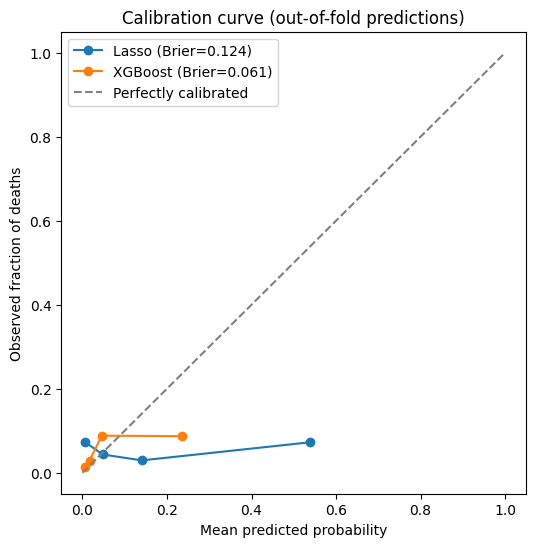

In [97]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

for y_true, y_prob, label in [(y_true_lasso, y_prob_lasso, 'Lasso'),
                                (y_true_xgb, y_prob_xgb, 'XGBoost')]:
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=4, strategy='quantile')
    brier = brier_score_loss(y_true, y_prob)
    ax.plot(mean_pred, frac_pos, marker='o', label=f'{label} (Brier={brier:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction of deaths')
ax.set_title('Calibration curve (out-of-fold predictions)')
ax.legend()
plt.show()

### Calibration curve :

It checks whether our predicted probabilities mean what they say.

Inference:
1. Points sitting on the diagonal (y = x) → well-calibrated (patients called "40% risk" really did die ~40% of the time).

2. Points above the diagonal → model underestimates risk in that range.

3. Points below the diagonal → model overestimates risk in that range.

In our case: only 15 deaths spread across 4 buckets means very few data points per bucket, so a jumpy, noisy line is formed rather than a clean diagonal. That's a sample-size limitation.

# Feature Selection Stability

In [98]:
lasso_stability = nested_feature_stability(lasso_grid, X, y, groups, outer_cv, feature_cols, model_type='lasso')
xgb_stability = nested_feature_stability(xgb_grid, X, y, groups, outer_cv, feature_cols, model_type='xgb')

In [99]:
lasso_selection_rate = (
    lasso_stability.assign(selected=lasso_stability['value'] != 0)
    .groupby('feature')['selected']
    .sum()
    .sort_values(ascending=False)
)
print(lasso_selection_rate[lasso_selection_rate > 0].to_string())

feature
ordered_pH                                      5
first_Potassium                                 5
age_at_admission                                5
total_urine_output_24h_ml                       5
admission_location_INFORMATION NOT AVAILABLE    4
admission_location_TRANSFER FROM HOSPITAL       4
first_Respiratory Rate                          4
max_Non Invasive Blood Pressure diastolic       4
max_O2 saturation pulseoxymetry                 4
ordered_Lactate                                 4
min_Lactate                                     4
first_O2 saturation pulseoxymetry               4
first_Sodium                                    4
admission_type_DIRECT EMER.                     4
ordered_Estimated GFR (MDRD equation)           3
max_GCS - Eye Opening                           3
max_Temperature Fahrenheit                      3
first_Urea Nitrogen                             3
max_GCS - Motor Response                        3
first_Non Invasive Blood Pressure diastoli

In [100]:
xgb_stability['in_top10'] = xgb_stability.groupby('fold')['value'].rank(ascending=False) <= 10

xgb_summary = xgb_stability.groupby('feature').agg(
    mean_importance=('value', 'mean'),
    times_in_top10=('in_top10', 'sum')
).sort_values('times_in_top10', ascending=False)

print(xgb_summary.head(20).to_string())

                                             mean_importance  times_in_top10
feature                                                                     
min_Lactate                                         0.039908               4
max_Non Invasive Blood Pressure mean                0.027909               3
max_Non Invasive Blood Pressure diastolic           0.038846               3
first_Urea Nitrogen                                 0.031627               3
first_Heart Rate                                    0.028988               3
first_Sodium                                        0.028198               3
min_O2 saturation pulseoxymetry                     0.050496               3
first_PTT                                           0.021472               2
first_Lactate                                       0.034069               2
max_Alkaline Phosphatase                            0.010896               1
first_Non Invasive Blood Pressure diastolic         0.024096               1

# Learnings :  

1. I got to apply my learning from 100 Days of ML from Campus X.

2. Here's the actual order things happened in the notebook, start to finish:
* Raw data loading - admissions, patients, labevents, chartevents, microbiologyevents, outputevents, procedureevents, transfers loaded from the MIMIC-IV demo CSVs.
* Time-windowing — every source table filtered to admittime ≤ charttime ≤ admittime + 24h, before anything else. This happens first because every downstream step depends on only seeing "first 24 hours" data.
* Feature extraction (building raw features from the windowed data):
Labs split into Tier 1/2/3, sorted by charttime, aggregated (first, or min/max/first for Tier 3).
Vitals aggregated the same way.
GCS components mapped from text to numeric scores, then aggregated.
Other engineered features: blood cultures sent, procedures, ICU transfer flag, 24h urine output, age at admission.
All merged together into one features table, keyed by hadm_id.
* Demographic merge — admission_type, admission_location (and gender, from a separate patients merge) added. race/insurance/marital_status/language deliberately excluded here (the ethics decision).
* Missing-data handling (structural, not statistical) — 100%-missing columns dropped; near-zero-variance columns reviewed; one column dropped from each highly-correlated pair (PT/INR). This happens on the full features table, before any train/test split — a low-risk, dataset-structure decision, not a data-dependent statistic like a mean or scaler.
* Categorical encoding — pd.get_dummies on gender/admission_type/admission_location.
* Target merge — hospital_expire_flag attached last, only after all feature engineering was finalized — so feature engineering was never influenced by the outcome.
* feature_cols defined — the final list of predictor columns, everything above excluding IDs and the target.
* X, y, groups set up — X = features[feature_cols], y = hospital_expire_flag, groups = subject_id.
* Model pipelines built — SimpleImputer(median) → StandardScaler → LogisticRegression (Lasso) as one Pipeline; XGBClassifier alone (trees don't need scaling/imputation the same way, though XGBoost can natively handle missing values too).
* Imputation and scaling actually happen here — inside nested CV, refit fresh on each fold's training data, not once on the full dataset. This is the key ordering point: steps 5-6 (structural cleanup, encoding) happened once on the whole dataset because they're not data-dependent statistics; imputation/scaling (step 11) happen per fold because they are.
* Nested CV — inner loop tunes hyperparameters, outer loop scores the tuned pipeline on held-out patient groups.
* Final full-data fit, calibration, feature stability — done last, using the same fitted objects from step 12.

3. I investigated whether information available during the first 24 hours of hospitalization could support early mortality prediction, while explicitly dealing with temporal leakage, severe class imbalance, clinical missingness, repeated admissions, and the trade-off between an interpretable sparse linear model and a nonlinear tree-based model.

4. I went from a single train/test split, to catching leakage in re-evaluating tuned hyperparameters, to catching patient-level leakage, to catching degenerate folds breaking the metric, to fixing the fitting problem underneath that, to adding calibration and stability checks.
